# Advanced DOT Traffic Analysis 
This pipeline ingests NYC Yellow Taxi data, maps it to real neighborhoods, categorizes trips into Rush Hour windows, and joins an external Weather API to prove how rain impacts congestion.

In [1]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import os
import dataframe_image as dfi

# Ensure output directory exists
os.makedirs('output', exist_ok=True)

# Load Business Configurations from YAML
with open('config.yaml', 'r') as file:
    config = yaml.safe_load(file)

print("✅ Loaded Business Configurations from config.yaml")
display(config)

✅ Loaded Business Configurations from config.yaml


{'data_cleaning': {'max_speed_mph_outlier': 80},
 'business_logic': {'morning_rush_start_hour': 7,
  'morning_rush_end_hour': 9,
  'evening_rush_start_hour': 16,
  'evening_rush_end_hour': 19},
 'metrics': {'min_total_trips': 1000,
  'min_distance_miles': 1.5,
  'top_n_worst_routes': 15}}

In [2]:
# --- 1. INGEST MULTIPLE SOURCES ---
print("Loading Parquet and CSV data...")
df_trips = pd.read_parquet('data/yellow_tripdata_2026-04.parquet')
df_zones = pd.read_csv('data/taxi_zone_lookup.csv')

print("Fetching live historical weather data from Open-Meteo API...")
url = "https://archive-api.open-meteo.com/v1/archive?latitude=40.7143&longitude=-74.006&start_date=2026-04-01&end_date=2026-04-30&hourly=precipitation"
weather_data = requests.get(url).json()

# Convert weather JSON to a Pandas DataFrame
df_weather = pd.DataFrame(weather_data['hourly'])
df_weather['time'] = pd.to_datetime(df_weather['time'])
df_weather['is_raining'] = df_weather['precipitation'] > 0

print(f"Successfully loaded {len(df_trips):,} trips, {len(df_zones)} zones, and {len(df_weather)} hours of weather data.")

Loading Parquet and CSV data...
Fetching live historical weather data from Open-Meteo API...
Successfully loaded 3,831,240 trips, 265 zones, and 720 hours of weather data.


In [3]:
# --- 2. VALIDATE & CLEAN DATA ---
initial_count = len(df_trips)

# Calculate duration in minutes
df_trips['trip_duration_minutes'] = (df_trips['tpep_dropoff_datetime'] - df_trips['tpep_pickup_datetime']).dt.total_seconds() / 60.0

# Apply rules (No teleportation, no 0 distances)
df_clean = df_trips[
    (df_trips['trip_distance'] > 0) & 
    (df_trips['trip_duration_minutes'] > 0) & 
    (df_trips['trip_duration_minutes'] < 300)
].copy()

df_clean['speed_mph'] = df_clean['trip_distance'] / (df_clean['trip_duration_minutes'] / 60.0)

# Apply YAML Config for Outlier Removal
max_speed = config['data_cleaning']['max_speed_mph_outlier']
df_clean = df_clean[df_clean['speed_mph'] <= max_speed]

print(f"Dropped {initial_count - len(df_clean):,} invalid rows.")

Dropped 144,220 invalid rows.


In [4]:
# --- 3. MODELING TEMPORAL & WEATHER WORKFLOW ---
print("Applying temporal and weather logic...")

# Map Zone Names
df_clean = df_clean.merge(df_zones[['LocationID', 'Zone']], left_on='PULocationID', right_on='LocationID', how='left')
df_clean = df_clean.rename(columns={'Zone': 'Pickup_Zone'})
df_clean = df_clean.merge(df_zones[['LocationID', 'Zone']], left_on='DOLocationID', right_on='LocationID', how='left')
df_clean = df_clean.rename(columns={'Zone': 'Dropoff_Zone'})
df_clean['Route'] = df_clean['Pickup_Zone'] + " to " + df_clean['Dropoff_Zone']

# Temporal Modeling (Rush Hour) using YAML Config
df_clean['pickup_hour'] = df_clean['tpep_pickup_datetime'].dt.hour

m_start = config['business_logic']['morning_rush_start_hour']
m_end = config['business_logic']['morning_rush_end_hour']
e_start = config['business_logic']['evening_rush_start_hour']
e_end = config['business_logic']['evening_rush_end_hour']

def categorize_time(hour):
    if m_start <= hour <= m_end: return 'Morning Rush'
    elif e_start <= hour <= e_end: return 'Evening Rush'
    else: return 'Off-Peak'
    
df_clean['time_of_day'] = df_clean['pickup_hour'].apply(categorize_time)

# Weather Merge (Round trip time down to nearest hour to match weather data)
df_clean['weather_join_time'] = df_clean['tpep_pickup_datetime'].dt.floor('h')
df_clean = df_clean.merge(df_weather[['time', 'is_raining']], left_on='weather_join_time', right_on='time', how='left')

df_clean[['tpep_pickup_datetime', 'time_of_day', 'is_raining', 'speed_mph']].head()

Applying temporal and weather logic...


,tpep_pickup_datetime,time_of_day,is_raining,speed_mph
0,2026-04-01 00:40:05,Off-Peak,False,13.280632
1,2026-04-01 00:09:19,Off-Peak,False,36.345205
2,2026-04-01 00:15:29,Off-Peak,False,24.512000
3,2026-04-01 00:14:20,Off-Peak,False,35.154512
4,2026-04-01 00:04:53,Off-Peak,False,11.458432


### Final Output: Proving that Rain + Rush Hour ruins NYC Traffic

Calculating the absolute worst routes using YAML Configs...
✅ Pipeline complete! Top 15 Worst Corridors (> 1.5 miles, > 1000 trips):


,Route,Evening Rush (Rain: False),Evening Rush (Rain: True),Morning Rush (Rain: False),Morning Rush (Rain: True),Off-Peak (Rain: False),Off-Peak (Rain: True),overall_speed_mph,average_distance_miles,total_trips
10,Upper East Side South to Garment District,5.420000,6.150000,6.930000,6.690000,6.110000,6.300000,6.089695,1.960000,1121
7,Penn Station/Madison Sq West to Midtown East,5.570000,5.500000,6.220000,5.800000,6.170000,6.870000,6.092966,1.520000,3535
14,West Chelsea/Hudson Yards to Murray Hill,5.680000,5.200000,6.250000,5.230000,6.370000,6.400000,6.115297,1.640000,1667
0,East Chelsea to Midtown Center,5.880000,5.580000,6.870000,6.690000,6.090000,6.390000,6.165674,1.750000,3162
12,West Chelsea/Hudson Yards to Midtown Center,6.170000,5.870000,6.600000,5.960000,6.340000,6.150000,6.290807,1.810000,2352
2,East Chelsea to Murray Hill,5.950000,5.300000,6.600000,6.560000,6.460000,6.380000,6.319637,1.540000,2786
13,West Chelsea/Hudson Yards to Midtown East,6.040000,5.590000,6.220000,6.530000,6.660000,6.680000,6.403286,2.090000,1059
4,Midtown Center to East Chelsea,5.400000,5.550000,7.590000,7.220000,6.630000,7.080000,6.426519,1.750000,4014
9,Union Sq to Times Sq/Theatre District,5.220000,5.080000,8.120000,8.060000,6.840000,6.660000,6.476622,1.570000,2862
3,East Chelsea to UN/Turtle Bay South,5.890000,6.550000,6.430000,5.380000,6.760000,6.760000,6.550310,1.960000,1132


✅ Saved Heatmap to output/pandas_heatmap.png
✅ Saved Chart to output/bottleneck_chart.png


/var/folders/6n/fzsly8555t9f4pb8gyyxyb8r0000gn/T/ipykernel_38211/1752150275.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


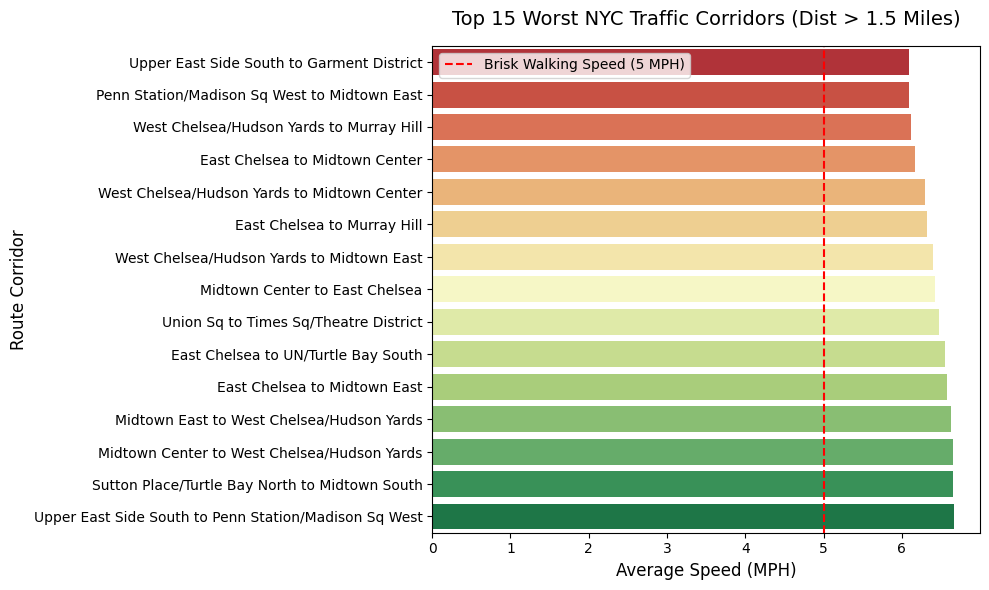

✅ Saved CSV Data to output/advanced_traffic_report.csv


In [5]:
# --- 4. ADVANCED METRICS OUTPUT ---
print("Calculating the absolute worst routes using YAML Configs...")

route_stats = df_clean.groupby('Route').agg(
    overall_speed_mph=('speed_mph', 'mean'),
    average_distance_miles=('trip_distance', 'mean'),
    total_trips=('speed_mph', 'count')
).reset_index()

# CRITICAL FILTER: Apply business limits from config.yaml
min_trips = config['metrics']['min_total_trips']
min_dist = config['metrics']['min_distance_miles']
top_n = config['metrics']['top_n_worst_routes']

route_stats = route_stats[
    (route_stats['total_trips'] >= min_trips) & 
    (route_stats['average_distance_miles'] >= min_dist)
]

top_worst = route_stats.sort_values('overall_speed_mph').head(top_n)
worst_route_names = top_worst['Route'].tolist()

# Filter the main dataset for ONLY those top worst bottlenecks
df_worst = df_clean[df_clean['Route'].isin(worst_route_names)]

pivot_report = df_worst.pivot_table(
    index='Route',
    columns=['time_of_day', 'is_raining'],
    values='speed_mph',
    aggfunc='mean'
).round(2)

pivot_report.columns = [f"{time} (Rain: {rain})" for time, rain in pivot_report.columns]
flat_report = pivot_report.reset_index()

final_table = flat_report.merge(top_worst, on='Route', how='left')
final_table['average_distance_miles'] = final_table['average_distance_miles'].round(2)
final_table = final_table.sort_values('overall_speed_mph', ascending=True)

print(f"✅ Pipeline complete! Top {top_n} Worst Corridors (> {min_dist} miles, > {min_trips} trips):")

styled_table = final_table.style.background_gradient(
    cmap='RdYlGn', 
    axis=None, 
    subset=[
        'Evening Rush (Rain: False)', 'Evening Rush (Rain: True)', 
        'Morning Rush (Rain: False)', 'Morning Rush (Rain: True)', 
        'Off-Peak (Rain: False)', 'Off-Peak (Rain: True)', 'overall_speed_mph'
    ]
)
display(styled_table)

# Generate & Save Heatmap Image
try:
    dfi.export(styled_table, 'output/pandas_heatmap.png', table_conversion='matplotlib')
    print("✅ Saved Heatmap to output/pandas_heatmap.png")
except Exception as e:
    print(f"Could not export image: {e}")

# Generate a beautiful Bar Chart for the Presentation
plt.figure(figsize=(10, 6))
sns.barplot(
    data=final_table, 
    x='overall_speed_mph', 
    y='Route', 
    palette='RdYlGn' 
)

plt.title(f'Top {top_n} Worst NYC Traffic Corridors (Dist > {min_dist} Miles)', fontsize=14, pad=15)
plt.xlabel('Average Speed (MPH)', fontsize=12)
plt.ylabel('Route Corridor', fontsize=12)
plt.axvline(x=5.0, color='red', linestyle='--', label='Brisk Walking Speed (5 MPH)')
plt.legend()
plt.tight_layout()
plt.savefig('output/bottleneck_chart.png', dpi=150)
print("✅ Saved Chart to output/bottleneck_chart.png")
plt.show()

# Save to CSV
final_table.to_csv('output/advanced_traffic_report.csv', index=False)
print("✅ Saved CSV Data to output/advanced_traffic_report.csv")